# Student Performance Prediction using PyTorch Linear Regression

## Setup

In [19]:
# Uncomment if needed
# !pip install kagglehub torch scikit-learn pandas matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

import kagglehub

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Load Dataset

In [20]:
dataset_path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")
print("Dataset path:", dataset_path)

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        print(os.path.relpath(os.path.join(root, f), dataset_path))

Dataset path: /home/sodagari/.cache/kagglehub/datasets/nikhil7280/student-performance-multiple-linear-regression/versions/1
Student_Performance.csv


In [21]:
csv_path = os.path.join(dataset_path, "Student_Performance.csv")
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Could not find Student_Performance.csv at: {csv_path}")

df = pd.read_csv(csv_path)


## Explore Data

In [22]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [23]:
print("Dataset shape:", df.shape)
print("Dataset columns:", df.columns.tolist())
print("Missing values:", df.isnull().sum())
print("Data types:", df.dtypes)


Dataset shape: (10000, 6)
Dataset columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']
Missing values: Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
Data types: Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [24]:
df.describe(include="all")

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


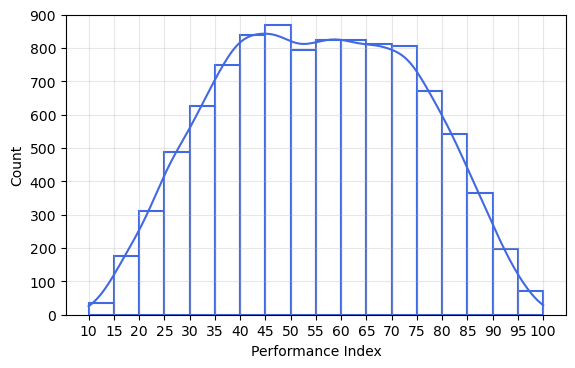

In [25]:
figure = plt.figure(figsize=(5, 3))
axes = figure.add_axes([0,0,1,1])

axes.set_ylim(0, 900)
axes.set_xticks(np.arange(0,101,5))

sns.histplot(df["Performance Index"], binwidth=5, kde=True, fill=False, color="royalblue", ax=axes)

axes.grid(alpha=0.3)
plt.show()


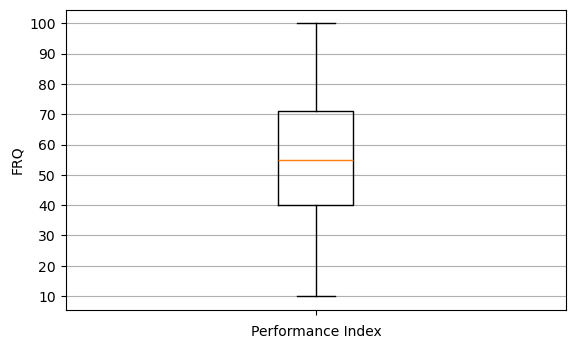

In [26]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.boxplot(df['Performance Index'])

axes.set_xlabel('Performance Index')
axes.set_ylabel('FRQ')

axes.xaxis.set_ticklabels([])
axes.yaxis.set_ticks(np.arange(10, 101, 10))

axes.grid(axis = 'y')

plt.show()

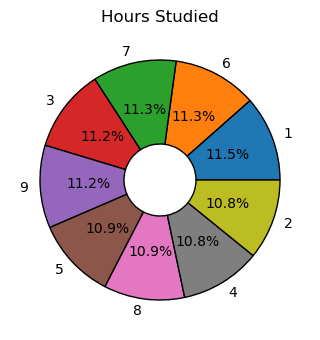

In [27]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_hours_studied = df['Hours Studied'].value_counts()

axes.pie(df_count_hours_studied,
         labels = df_count_hours_studied.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.7},
         autopct = '%1.1f%%'
         )

axes.set_title('Hours Studied')

plt.show()

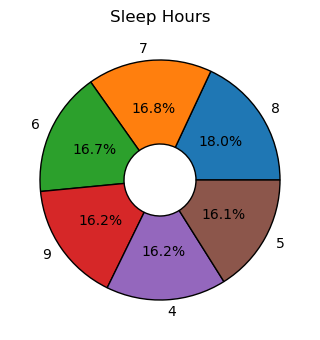

In [28]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_sleep_hours = df['Sleep Hours'].value_counts()

axes.pie(df_count_sleep_hours,
         labels = df_count_sleep_hours.index,
         wedgeprops = {'edgecolor': 'black', 'width': 0.7},
         autopct = '%1.1f%%'
         )

axes.set_title('Sleep Hours')

plt.show()

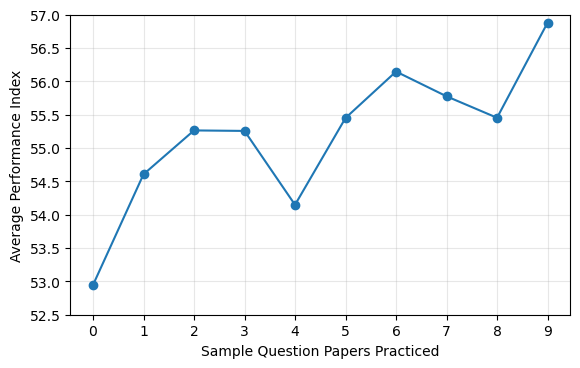

In [29]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_question_practiced	= df.groupby('Sample Question Papers Practiced')['Performance Index'].mean()

axes.plot(average_performance_by_question_practiced.index,
          average_performance_by_question_practiced,
          marker = 'o'
          )

axes.set_ylim(52.5, 57)

axes.set_xlabel('Sample Question Papers Practiced')
axes.set_ylabel('Average Performance Index')

axes.xaxis.set_ticks(np.arange(0, 10, 1))

axes.grid(alpha = 0.3)

plt.show()

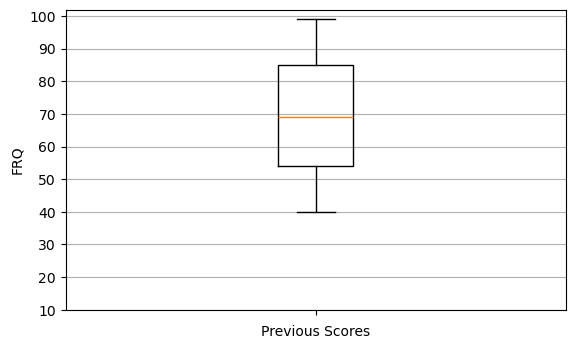

In [30]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

axes.boxplot(df['Previous Scores'])

axes.set_xlabel('Previous Scores')
axes.set_ylabel('FRQ')

axes.xaxis.set_ticklabels([])
axes.yaxis.set_ticks(np.arange(10, 101, 10))

axes.grid(axis = 'y')

plt.show()

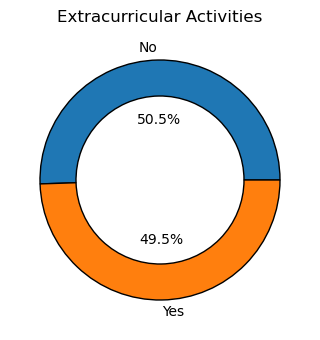

In [31]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

df_count_extracurricular_activities = df['Extracurricular Activities'].value_counts()

axes.pie(df_count_extracurricular_activities,
         labels = ['No', 'Yes'],
         wedgeprops = {'edgecolor': 'black', 'width': 0.3},
         autopct = '%1.1f%%',
         pctdistance = 0.5
         )

axes.set_title('Extracurricular Activities')

plt.show()

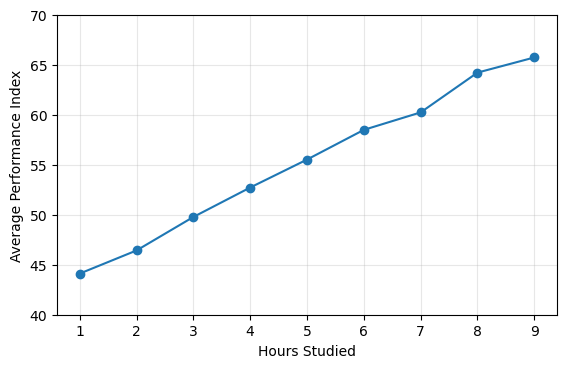

In [32]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_hours_studied = df.groupby('Hours Studied')['Performance Index'].mean()


axes.plot(average_performance_by_hours_studied.index,
          average_performance_by_hours_studied,
          marker = 'o'
          )

axes.set_ylim(40, 70)

axes.set_xlabel('Hours Studied')
axes.set_ylabel('Average Performance Index')

axes.grid(alpha = 0.3)

plt.show()

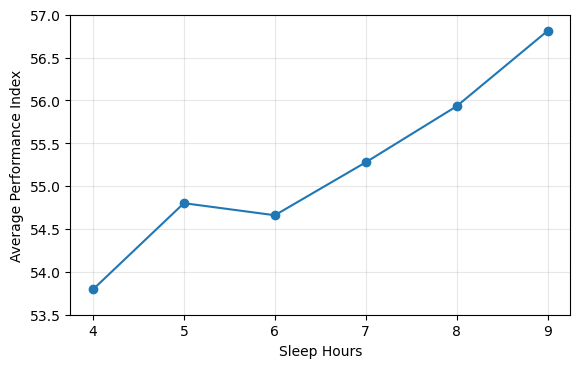

In [33]:
figure = plt.figure(figsize = (5, 3))
axes = figure.add_axes([0, 0, 1, 1])

average_performance_by_sleep_hours = df.groupby('Sleep Hours')['Performance Index'].mean()

axes.plot(average_performance_by_sleep_hours.index,
          average_performance_by_sleep_hours,
          marker = 'o'
          )

axes.set_ylim(53.5, 57)

axes.set_xlabel('Sleep Hours')
axes.set_ylabel('Average Performance Index')

axes.grid(alpha = 0.3)

plt.show()

## Preprocess Data

In [34]:
data = df.copy()

data.columns = data.columns.str.strip()

if "Extracurricular Activities" in data.columns:
    data["Extracurricular Activities"] = data["Extracurricular Activities"].map({"Yes": 1, "No": 0})

if data["Extracurricular Activities"].isnull().any():
    raise ValueError("Missing values found in 'Extracurricular Activities' after mapping. Please check the data.")

target_goal = "Performance Index"
features = [col for col in data.columns if col != target_goal]

X = data[features].values.astype(np.float32)
y = data[target_goal].values.astype(np.float32).reshape(-1, 1)

print("Features:", features)
print("X shape:", X.shape)
print("y shape:", y.shape)



Features: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']
X shape: (10000, 5)
y shape: (10000, 1)


## Prepare Training and Test Sets

In [35]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)  

print("Train shape:", train_X_scaled.shape)
print("Test shape:", test_X_scaled.shape)

Train shape: (8000, 5)
Test shape: (2000, 5)


In [36]:
X_train_tensor = torch.tensor(train_X_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(train_y, dtype=torch.float32)

X_test_tensor = torch.tensor(test_X_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(test_y, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Build the Model

In [37]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)
model = LinearRegressionModel(input_dim=X_train_tensor.shape[1]).to(device)
print(model)

LinearRegressionModel(
  (linear): Linear(in_features=5, out_features=1, bias=True)
)


## Train the Model

In [38]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
num_epochs = 60

train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}')

Epoch [1/60], Loss: 3222.0043
Epoch [2/60], Loss: 2888.8340
Epoch [3/60], Loss: 2588.9577
Epoch [4/60], Loss: 2318.4502
Epoch [5/60], Loss: 2073.6753
Epoch [6/60], Loss: 1851.7878
Epoch [7/60], Loss: 1650.0572
Epoch [8/60], Loss: 1466.4950
Epoch [9/60], Loss: 1299.4211
Epoch [10/60], Loss: 1147.2268
Epoch [11/60], Loss: 1008.4800
Epoch [12/60], Loss: 882.1332
Epoch [13/60], Loss: 767.1535
Epoch [14/60], Loss: 662.8281
Epoch [15/60], Loss: 568.4415
Epoch [16/60], Loss: 483.3982
Epoch [17/60], Loss: 407.2334
Epoch [18/60], Loss: 339.4433
Epoch [19/60], Loss: 279.5945
Epoch [20/60], Loss: 227.2679
Epoch [21/60], Loss: 182.0391
Epoch [22/60], Loss: 143.4264
Epoch [23/60], Loss: 110.9621
Epoch [24/60], Loss: 84.1750
Epoch [25/60], Loss: 62.5054
Epoch [26/60], Loss: 45.4021
Epoch [27/60], Loss: 32.2835
Epoch [28/60], Loss: 22.5573
Epoch [29/60], Loss: 15.6315
Epoch [30/60], Loss: 10.9311
Epoch [31/60], Loss: 7.9121
Epoch [32/60], Loss: 6.0952
Epoch [33/60], Loss: 5.0787
Epoch [34/60], Loss: 

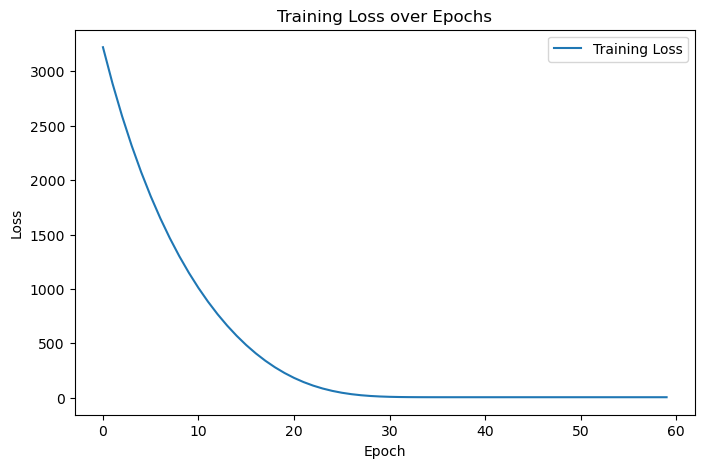

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

## Evaluate Performance

In [40]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor.to(device)).cpu()

y_pred = y_pred_tensor.numpy()
mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_y, y_pred)

print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² Score: {r2:.4f}")
    

Test MSE: 4.0794
Test RMSE: 2.0197
Test R² Score: 0.9890


## Result Visualization

In [41]:
results = pd.DataFrame({
    "Actual": test_y.flatten(),
    "Predicted": y_pred.flatten()
})

results.head(10)


,Actual,Predicted
0,51.0,54.681713
1,20.0,22.537174
2,46.0,47.887867
3,28.0,31.266241
4,41.0,43.026566
5,59.0,59.138664
6,48.0,45.794247
7,87.0,86.521545
8,37.0,37.773193
9,73.0,72.044495


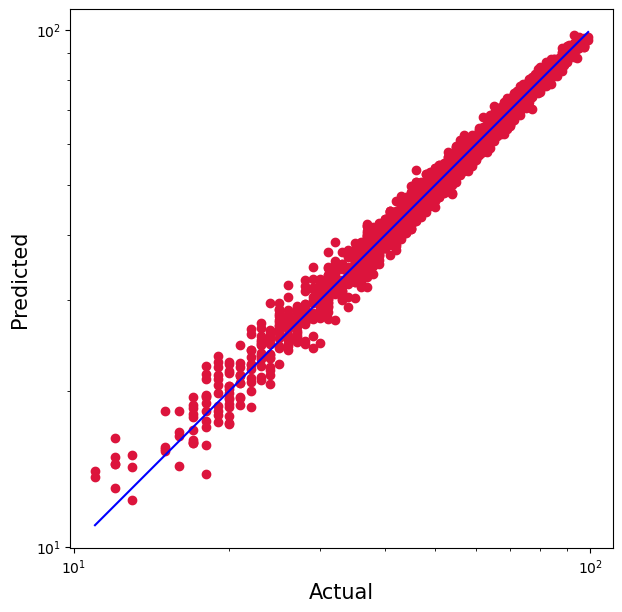

In [42]:
plt.figure(figsize=(7,7))
plt.scatter(test_y, y_pred, c='crimson')
plt.yscale('log')
plt.xscale('log')

p1 = max(max(y_pred), max(test_y))
p2 = min(min(y_pred), min(test_y))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Actual', fontsize=15)
plt.ylabel('Predicted', fontsize=15)
plt.axis('equal')
plt.show()

In [43]:
weights = model.linear.weight.detach().cpu().numpy().flatten()
bias = model.linear.bias.detach().cpu().numpy()[0]

coef_df = pd.DataFrame({
    "Feature": features,
    "Weight": weights
}).sort_values(by="Weight", key=lambda s: s.abs(), ascending=False)

print("Bias:", bias)
coef_df

Bias: 55.280647


,Feature,Weight
1,Previous Scores,17.638079
0,Hours Studied,7.442160
3,Sleep Hours,0.823847
4,Sample Question Papers Practiced,0.587434
2,Extracurricular Activities,0.280129


In [44]:
sample_index = 5
sample_features = test_X_scaled[sample_index:sample_index+1]
sample_tensor = torch.tensor(sample_features, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    sample_pred = model(sample_tensor).cpu().numpy()[0, 0]

print("Actual   :", test_y[sample_index, 0])
print("Predicted:", sample_pred)

Actual   : 59.0
Predicted: 59.138664
